In [5]:
import gymnasium as gym
from RLCodeBase import ReinforcementLearningBase, plot_learning_curves, plot_avg_reward_dist, plot_learning_curves_with_confidence_intervals, plot_learning_curves_with_tolerance_intervals,perform_welch_ttest
from pathlib import Path
import numpy as np
from collections import defaultdict

### First-Visit Monte Carlo Control Implementation

The `MonteCarloControl` class implements the Monte Carlo control algorithm to learn an optimal policy in a Reinforcement Learning environment.  

#### **Main Methods:**
- **`train(num_episodes)`**:  
  - Runs multiple training episodes.  
  - Applies an epsilon-greedy policy for action selection.  
  - Records metrics such as total return and steps per episode.  
  - Updates the Q-function using the First-Visit Monte Carlo method.  
  - Gradually reduces `epsilon` to decrease exploration over time.  

- **`update_Q(episode_history)`**:  
  - Computes the cumulative return (`G`) in reverse order.  
  - Applies the **First-Visit** method: updates `Q[state][action]` only the first time it appears in the episode.  

#### **Key Parameters:**
- `gamma`: Discount factor for return computation.  
- `epsilon`: Exploration probability in the epsilon-greedy policy.  
- `min_epsilon`: Minimum exploration limit.  
- `epsilon_decay`: Reduction factor for `epsilon` after each episode.  

#### **Q-Value Update:**
The action-value function \( Q(s, a) \) is updated using the average of observed returns:  
$
Q(s, a) = \frac{\sum G}{\text{visits}(s, a)}
$

where \( G \) is the discounted cumulative return.

This method enables the iterative improvement of the policy toward an optimal strategy as the agent learns from experience.  



In [6]:
class MonteCarloControl(ReinforcementLearningBase):
  def __init__(self, env, gamma, epsilon, min_epsilon, epsilon_decay):
    super().__init__(env, gamma, epsilon, min_epsilon, epsilon_decay)
    self.returns_sum = defaultdict(float)
    self.returns_count = defaultdict(float)
    self.return_per_steps=[]
    self.steps_per_episode=[]
  def train(self, num_episodes):

    for episode in range(num_episodes):
      episode_history = []
      state, _ = self.env.reset()
      done = False
      total_reward=0;
      steps=0
      while not done:
        action = self.epsilon_greedy_policy(state)
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        total_reward += reward
        episode_history.append((state, action, reward))
        state = next_state
        steps+=1

      self.episode_returns.append(total_reward)
      self.return_per_steps.append(total_reward/steps)
      self.steps_per_episode.append(steps)
      self.update_Q(episode_history)
      # Decay epsilon
      self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
      self.episode_epsilon.append(self.epsilon)
      # Print progress
      if (episode + 1) % 1000 == 0:
          print(f"Episode: {episode + 1}, Epsilon: {self.epsilon:.4f}, Return: {total_reward:.4f}")

  def update_Q(self, episode_history):
    # Update Q-values using First-Visit MC
    G = 0  # Return (discounted cumulative reward)
    visited_state_actions = set()  # Track visited state-action pairs

    for t in reversed(range(len(episode_history))):
        state, action, reward = episode_history[t]
        G = self.gamma * G + reward

        # First-visit: only update if (state, action) hasn't been visited in this episode
        if (state, action) not in visited_state_actions:
            visited_state_actions.add((state, action))
            self.returns_sum[(state, action)] += G
            self.returns_count[(state, action)] += 1
            self.Q[state][action] = self.returns_sum[(state, action)] / self.returns_count[(state, action)]

### Temporal Difference (TD) Learning Implementation - Q learning

The `TD_learning` class implements a Temporal Difference (TD) learning algorithm, specifically **Q-Learning**, for policy improvement in Reinforcement Learning environments.

#### **Main Methods:**
- **`train(num_episodes)`**:  
  - Runs multiple training episodes.  
  - Applies an epsilon-greedy policy for action selection.  
  - Updates the Q-function using **Q-Learning (TD update)** after each step.  
  - Gradually reduces `epsilon` to decrease exploration over time.  
  - Tracks episode metrics such as total return and steps taken.

- **`update_Q(state, action, reward, next_state)`**:  
  - Selects the **best action** in `next_state` using a greedy approach.  
  - Updates \( Q(s, a) \) using the **TD update rule**:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)
$$

#### **Key Parameters:**
- **Discount factor**:  
  $ \gamma $ -  Controls how much future rewards matter.  
- **Exploration probability**:  
  $ \epsilon $ - Probability of choosing a random action (exploration).  
- **Minimum exploration limit**:  
  $ \epsilon_{\text{min}} $- The lowest value that \( \epsilon \) can decay to.  
- **Exploration decay rate**:  
  $ \epsilon_{\text{decay}} $- Multiplier that reduces \( \epsilon \) after each episode.  
- **Learning rate**:  
  $ \alpha $  -Determines how much new information overrides old Q-values.

#### **Q-Value Update Explanation:**
1. The **greedy action** \( a' \) is chosen in the next state \( s' \) as:

$$
a' = \arg\max_{a'} Q(s', a')
$$

2. The Q-value is updated using the reward \( r \) and the best estimated future value.

This method allows the agent to **learn an optimal policy** through direct interaction with the environment, refining its decision-making over time.


In [7]:
class TD_learning(ReinforcementLearningBase):
  def __init__(self, env, gamma, epsilon, min_epsilon, epsilon_decay, alpha):
    super().__init__(env, gamma, epsilon, min_epsilon, epsilon_decay)
    self.alpha = alpha
    self.return_per_steps=[]
    self.steps_per_episode=[]
  def train(self, num_episodes):

    for episode in range(num_episodes):
      state, _ = self.env.reset()
      done = False
      total_reward=0
      success = False
      steps=0
      while not done:
          action = self.epsilon_greedy_policy(state) #Epsilon greedy
          next_state, reward, terminated, truncated, _ = self.env.step(action)
          done = terminated or truncated
          total_reward+=reward
          self.update_Q(state, action, reward, next_state)
          state = next_state
          steps+=1
      # Decay epsilon
      self.steps_per_episode.append(steps)
      self.episode_returns.append(total_reward)
      self.return_per_steps.append(total_reward/steps)
      self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

      if (episode + 1) % 100 == 0:
          print(f"Episode: {episode + 1}, Epsilon: {self.epsilon:.4f}, Return: {total_reward:.4f}, Alpha: {self.alpha}")

  def update_Q(self, state, action, reward, next_state):
    best_next_action = np.argmax(self.Q[next_state])  #
    self.Q[state][action] += self.alpha * (reward + self.gamma * self.Q[next_state][best_next_action] - self.Q[state][action])


### Monte Carlo Control (On-Policy) and Temporal Difference (TD) Learning (Off-Policy) for FrozenLake Environment

This notebook demonstrates two reinforcement learning techniques applied to the **FrozenLake-v1** environment:

1. **Monte Carlo Control (On-Policy)**
2. **Temporal Difference Learning (Off-Policy)**

Both methods are applied to learn an optimal policy for the agent in the FrozenLake environment, and the results are visualized.

#### **Hyperparameters:**
- **`NUM_EPISODES`**: Total number of training episodes to run.
- **`GAMMA`**: Discount factor used in the value estimation to weigh future rewards.
- **`EPSILON`**: Exploration rate used in epsilon-greedy policy for selecting actions.
- **`MIN_EPSILON`**: The minimum value \( \epsilon \) will decay to.
- **`EPSILON_DECAY`**: The decay factor for \( \epsilon \), which helps balance exploration and exploitation over time.
- **`ALPHA`**: The learning rate used in TD learning to control the magnitude of updates to the Q-values.



Monte Carlo control (On policy): Training...
Episode: 1000, Epsilon: 0.3677, Return: 0.0000
Episode: 2000, Epsilon: 0.1352, Return: 1.0000
Episode: 3000, Epsilon: 0.0497, Return: 1.0000
Episode: 4000, Epsilon: 0.0183, Return: 1.0000
Episode: 5000, Epsilon: 0.0100, Return: 1.0000
Episode: 6000, Epsilon: 0.0100, Return: 1.0000


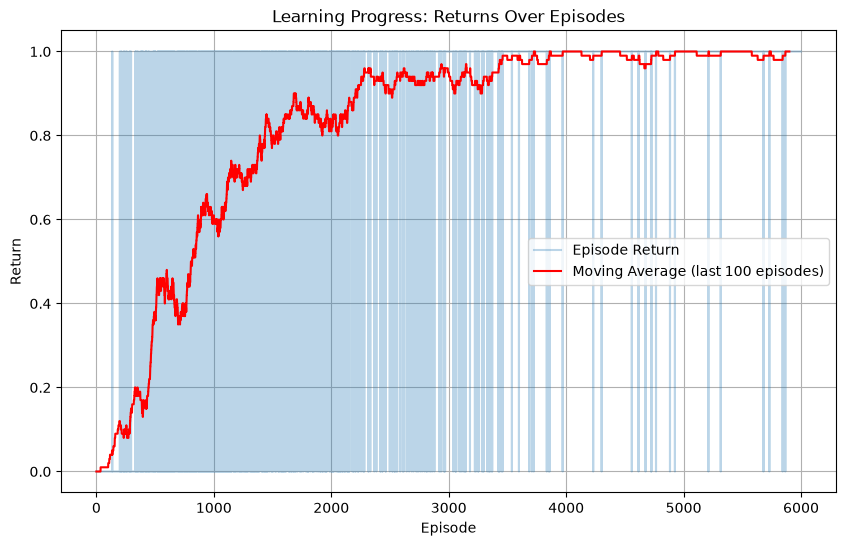

TD control (Off policy): Training...
Episode: 100, Epsilon: 0.9048, Return: 0.0000, Alpha: 0.01
Episode: 200, Epsilon: 0.8186, Return: 0.0000, Alpha: 0.01
Episode: 300, Epsilon: 0.7407, Return: 0.0000, Alpha: 0.01
Episode: 400, Epsilon: 0.6702, Return: 1.0000, Alpha: 0.01
Episode: 500, Epsilon: 0.6064, Return: 0.0000, Alpha: 0.01
Episode: 600, Epsilon: 0.5486, Return: 1.0000, Alpha: 0.01
Episode: 700, Epsilon: 0.4964, Return: 1.0000, Alpha: 0.01
Episode: 800, Epsilon: 0.4491, Return: 1.0000, Alpha: 0.01
Episode: 900, Epsilon: 0.4064, Return: 1.0000, Alpha: 0.01
Episode: 1000, Epsilon: 0.3677, Return: 1.0000, Alpha: 0.01
Episode: 1100, Epsilon: 0.3327, Return: 1.0000, Alpha: 0.01
Episode: 1200, Epsilon: 0.3010, Return: 1.0000, Alpha: 0.01
Episode: 1300, Epsilon: 0.2724, Return: 1.0000, Alpha: 0.01
Episode: 1400, Epsilon: 0.2464, Return: 0.0000, Alpha: 0.01
Episode: 1500, Epsilon: 0.2230, Return: 1.0000, Alpha: 0.01
Episode: 1600, Epsilon: 0.2017, Return: 1.0000, Alpha: 0.01
Episode: 170

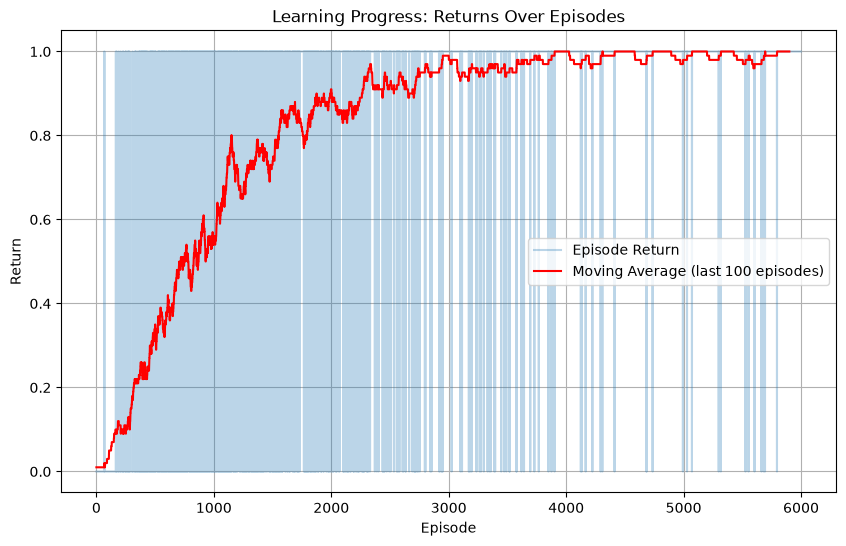

(1.0, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [11]:
# Hyperparameters
NUM_EPISODES = 6000  # Total number of episodes
GAMMA = 0.99  # Discount factor
EPSILON = 1 # Exploration rate
MIN_EPSILON = 0.01  # Minimum exploration rate
EPSILON_DECAY = 0.999  # Decay rate for exploration

# Initialize the FrozenLake environment
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False, render_mode="rgb_array")
video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)

mc_control = MonteCarloControl(env, GAMMA, EPSILON, MIN_EPSILON, EPSILON_DECAY)
print("Monte Carlo control (On policy): Training...")
mc_control.train(NUM_EPISODES)
mc_control.plot_learning_progress()
mc_video_path = video_dir / "taxi_mc_learning.gif"
mc_control.evaluate_policy(num_episodes=10, save_video=True, video_dir = str(mc_video_path))


# Hyperparameters
NUM_EPISODES = 6000  # Total number of episodes
GAMMA = 0.99  # Discount factor
EPSILON = 1 # Exploration rate
MIN_EPSILON = 0.01  # Minimum exploration rate
EPSILON_DECAY = 0.999  # Decay rate for exploration
ALPHA = 0.01

td_control = TD_learning(env, GAMMA, EPSILON, MIN_EPSILON, EPSILON_DECAY,ALPHA)
print("TD control (Off policy): Training...")
td_control.train(NUM_EPISODES)
td_control.plot_learning_progress()
q_learning_video_path = video_dir / "taxi_q_learning.gif"
td_control.evaluate_policy(num_episodes=10, save_video=True, video_dir = str(q_learning_video_path))


### Training Multiple Runs for Monte Carlo Control (On-Policy) and Temporal Difference Learning (Off-Policy)

This section demonstrates the training of **Monte Carlo Control (MC)** and **Temporal Difference (TD) Learning** over multiple independent runs. The goal is to compare the performance of both algorithms by averaging the results across multiple runs.

#### **Key Variables:**
- **`returns`**: A dictionary that stores the cumulative return for each algorithm across multiple runs.
  - `returns["MC"]`: Stores returns for Monte Carlo control over multiple runs.
  - `returns["TD"]`: Stores returns for TD learning over multiple runs.
  
- **`returns_per_steps`**: A dictionary that stores the return per step (normalized reward per step) for each algorithm across multiple runs.
  - `returns_per_steps["MC"]`: Stores return per step for Monte Carlo control.
  - `returns_per_steps["TD"]`: Stores return per step for TD learning.

- **`N_RUNS`**: Number of independent runs for each algorithm. This is set to **10** in this case to allow a robust comparison.

---

### **Training Process for Multiple Runs:**

The training loop runs for **`N_RUNS`** times. In each run:
1. **Monte Carlo Control (On-Policy)** is trained using the `mc_control.train(NUM_EPISODES)` method.
   - After training, the **episode returns** and **return per step** are stored in the `returns` and `returns_per_steps` dictionaries.
   
2. **Temporal Difference (TD) Learning (Off-Policy)** is trained using the `td_control.train(NUM_EPISODES)` method.
   - Similarly, the **episode returns** and **return per step** are stored in the `returns` and `returns_per_steps` dictionaries.



In [12]:
returns={"MC":[],
         "TD":[]}
returns_per_steps={"MC":[],
"TD":[]}


N_RUNS=10
for _ in range(N_RUNS):
  #Monte Carlo
  mc_control = MonteCarloControl(env, GAMMA, EPSILON, MIN_EPSILON, EPSILON_DECAY)
  print("Monte Carlo control (On policy): Training...")
  mc_control.train(NUM_EPISODES)
  returns["MC"].append(mc_control.episode_returns)  # Store return curves
  returns_per_steps["MC"].append(mc_control.return_per_steps)

  #Temporal difference
  td_control = TD_learning(env, GAMMA, EPSILON, MIN_EPSILON, EPSILON_DECAY,ALPHA)
  print("TD control (Off policy): Training...")
  td_control.train(NUM_EPISODES)
  returns["TD"].append(td_control.episode_returns)
  returns_per_steps["TD"].append(td_control.return_per_steps)

Monte Carlo control (On policy): Training...
Episode: 1000, Epsilon: 0.3677, Return: 1.0000
Episode: 2000, Epsilon: 0.1352, Return: 1.0000
Episode: 3000, Epsilon: 0.0497, Return: 1.0000
Episode: 4000, Epsilon: 0.0183, Return: 1.0000
Episode: 5000, Epsilon: 0.0100, Return: 1.0000
Episode: 6000, Epsilon: 0.0100, Return: 1.0000
TD control (Off policy): Training...
Episode: 100, Epsilon: 0.9048, Return: 0.0000, Alpha: 0.01
Episode: 200, Epsilon: 0.8186, Return: 0.0000, Alpha: 0.01
Episode: 300, Epsilon: 0.7407, Return: 0.0000, Alpha: 0.01
Episode: 400, Epsilon: 0.6702, Return: 0.0000, Alpha: 0.01
Episode: 500, Epsilon: 0.6064, Return: 0.0000, Alpha: 0.01
Episode: 600, Epsilon: 0.5486, Return: 0.0000, Alpha: 0.01
Episode: 700, Epsilon: 0.4964, Return: 0.0000, Alpha: 0.01
Episode: 800, Epsilon: 0.4491, Return: 0.0000, Alpha: 0.01
Episode: 900, Epsilon: 0.4064, Return: 1.0000, Alpha: 0.01
Episode: 1000, Epsilon: 0.3677, Return: 1.0000, Alpha: 0.01
Episode: 1100, Epsilon: 0.3327, Return: 1.000

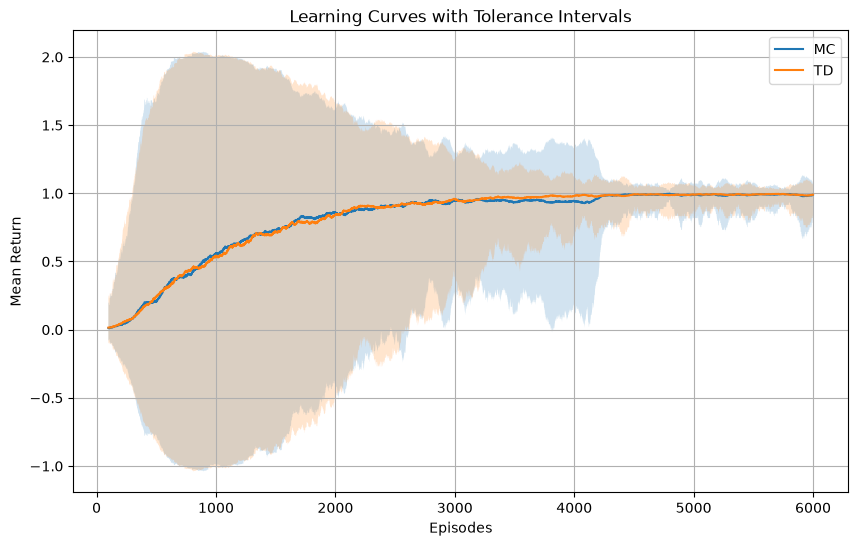

In [13]:
plot_learning_curves_with_tolerance_intervals(returns)

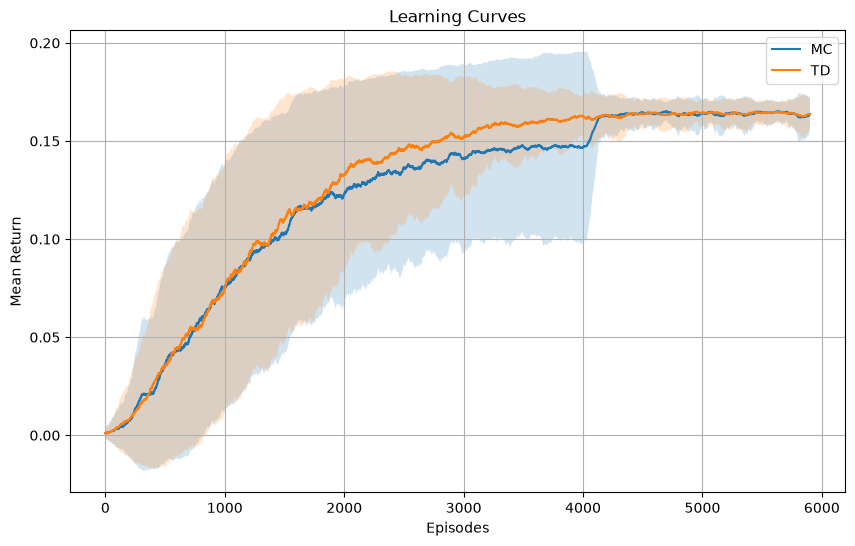

In [14]:
plot_learning_curves(returns_per_steps)

-TD appears to converge faster and more consistently, making it a good choice for problems requiring quicker learning.

-MC shows a more gradual learning process but eventually approaches similar performance, albeit with more variance.

In [15]:
test_results = perform_welch_ttest(returns["TD"], returns["MC"])

# Print statistical results
print("Welch's T-Test Results:")
print(f"T-Statistic: {test_results['t_statistic']}")
print(f"P-Value: {test_results['p_value']}")
print(f"\nTemporal Difference - Mean: {test_results['td_mean']:}, Std: {test_results['td_std']}")
print(f"Monte Carlo - Mean: {test_results['mc_mean']}, Std: {test_results['mc_std']}")

Welch's T-Test Results:
T-Statistic: 0.4786109477460407
P-Value: 0.6422425606336936

Temporal Difference - Mean: 0.80995, Std: 0.005099049778338624
Monte Carlo - Mean: 0.80695, Std: 0.019154513054900922


- TD has a slightly higher mean return than MC, indicating slightly better average performance.
- MC has a much higher standard deviation, meaning its performance is more inconsistent.
- TD shows much lower variance, making it more stable and predictable.
- MC has higher variability, which may indicate sensitivity to different conditions but can also mean higher risk.

In [16]:
test_results = perform_welch_ttest(returns_per_steps["TD"], returns_per_steps["MC"])

# Print statistical results
print("Welch's T-Test Results:")
print(f"T-Statistic: {test_results['t_statistic']}")
print(f"P-Value: {test_results['p_value']}")
print(f"\nTemporal Difference - Mean: {test_results['td_mean']:}, Std: {test_results['td_std']}")
print(f"Monte Carlo - Mean: {test_results['mc_mean']}, Std: {test_results['mc_std']}")

Welch's T-Test Results:
T-Statistic: 0.9229113360929302
P-Value: 0.38001466252471416

Temporal Difference - Mean: 0.12745904714840645, Std: 0.0007735823392497307
Monte Carlo - Mean: 0.12292594081968031, Std: 0.015513029565174396


- The mean return for TD is higher than for MC, meaning TD performs better on average.
- TD has significantly lower variance, making it a more stable and reliable learning method.
- MC has much higher variance, meaning its performance is more unpredictable and inconsistent.